# Marta Negri 75169
# Luca Davì 75214
## Task1

You will start by performing
object detection and evaluate it using three modern detectors: YOLOv11 [2], DETR [1], and
RT-DETR [7]. You should use YOLOv11 from Ultralytics, DETR from HuggingFace DETR and
RT-DETR from HuggingFace RT-DETR.
Your goal is to analyze and discuss their individual performance on the first 1000 samples
of the PASCAL VOC 2007 validation set

Run inference with each of the three models (YOLOv11, DETR, RF-DETR) on the selected
dataset subset: the first 1000 samples of PASCAL VOC validation set.

In [25]:
!pip install datasets transformers timm wandb matplotlib albumentations
!pip install pycocotools
!pip install torchmetrics
!pip install ultralytics
!pip install supervision
!pip install roboflow

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Importing the required libraries
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import torch
from ultralytics import YOLO
from transformers import pipeline

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.datasets import VOCDetection


In [3]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [4]:
# Model instantiation

yolo_model = YOLO('yolo11m.pt').to(device)
detr_model = pipeline('object-detection', model='facebook/detr-resnet-50',device=device)
rt_detr_model = pipeline('object-detection', model='PekingU/rtdetr_r50vd',device=device)

print(f'Models are on device: \nYOLO: {yolo_model.device}\nDETR device: {detr_model.device}\nRT-DETR device: {rt_detr_model.device}')


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Using a slow image processor as `use_fast` is unset and a slow processor was saved w

Models are on device: 
YOLO: cuda:0
DETR device: cuda
RT-DETR device: cuda


In [5]:

dataset = VOCDetection(root='data/', year='2007', image_set='val', download=False)
subset_size = 1000
subset = torch.utils.data.Subset(dataset, list(range(subset_size)))

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
VOC_CLASS_TO_ID = {cls_name: idx+1 for idx, cls_name in enumerate(VOC_CLASSES)}

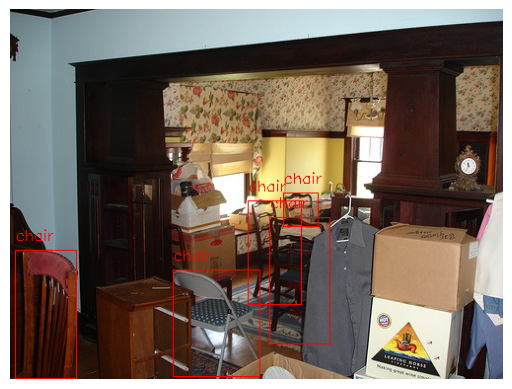

In [6]:
#Prepare in TorchMetrics format

targets_list = []
for img, target in subset:
    objs = target['annotation']['object']
    if not isinstance(objs, list):
        objs = [objs]
    boxes = []
    labels = []
    for obj in objs:
        b = obj['bndbox']
        boxes.append([float(b['xmin']), float(b['ymin']), float(b['xmax']), float(b['ymax'])])
        labels.append(VOC_CLASS_TO_ID[obj['name']])
    targets_list.append({
        'boxes': torch.tensor(boxes, dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.int64)
    })

# Display first image and its targets to verify: draw bounding boxes
img, target = subset[0]
boxes = target['annotation']['object']
if not isinstance(boxes, list):
    boxes = [boxes]
img_cv = np.array(img)
for box in boxes:
    b = box['bndbox']
    xmin, ymin, xmax, ymax = int(b['xmin']), int(b['ymin']), int(b['xmax']), int(b['ymax'])
    cv2.rectangle(img_cv, (xmin, ymin), (xmax, ymax), (255, 0, 0), 1)
    # Put class label
    class_name = box['name']
    cv2.putText(img_cv, class_name, (xmin, ymin-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
plt.imshow(img_cv)
plt.axis('off')
plt.show()

In [7]:
#convert predictions to VOC format

def convert_yolo_predictions(yolo_results, coco_classes, voc_map):
    yolo_boxes = torch.tensor(yolo_results.boxes.xyxy, dtype=torch.float32)
    yolo_scores = torch.tensor(yolo_results.boxes.conf, dtype=torch.float32)

    # Convert YOLO class indices → names → VOC ids
    labels_list = []
    for label_idx in yolo_results.boxes.cls:
        name = coco_classes[label_idx.item()]
        label_id = voc_map.get(name, 0)
        labels_list.append(label_id)

    yolo_labels = torch.tensor(labels_list, dtype=torch.int64)

    return {
        "boxes": yolo_boxes,
        "scores": yolo_scores,
        "labels": yolo_labels,
    }

def convert_detr_predictions(detr_results, voc_map, confidence=0.1):
    # Filter by confidence
    detr_results = [r for r in detr_results if r["score"] >= confidence]

    if len(detr_results) == 0:
        return None

    boxes_list = []
    scores_list = []
    labels_list = []

    for r in detr_results:
        box = r["box"]

        # Convert to xyxy
        if isinstance(box, dict):
            boxes_list.append([box["xmin"], box["ymin"], box["xmax"], box["ymax"]])
        else:
            x, y, w, h = box
            boxes_list.append([x, y, x + w, y + h])

        scores_list.append(r["score"])
        label_id = voc_map.get(r["label"], 0)
        labels_list.append(label_id)

    return {
        "boxes": torch.tensor(boxes_list, dtype=torch.float32),
        "scores": torch.tensor(scores_list, dtype=torch.float32),
        "labels": torch.tensor(labels_list, dtype=torch.int64),
    }

In [8]:
#evaluation loop

COCO_CLASSES = yolo_model.names

def evaluate_sample(img, target, yolo_model, detr_pipeline, rt_detr_pipeline, coco_classes, voc_map,
                    metric_yolo, metric_detr, metric_rt_detr, confidence=0.1):
    img_np = np.array(img)

    # --- YOLO ---
    yolo_raw = yolo_model(img_np, conf=confidence, verbose=False,device=device)[0]
    yolo_preds = convert_yolo_predictions(yolo_raw, coco_classes, voc_map)
    metric_yolo.update([yolo_preds], [target])

    # --- DETR ---
    detr_raw = detr_pipeline(img)
    detr_preds = convert_detr_predictions(detr_raw, voc_map, confidence=confidence)
    if detr_preds is not None:
        metric_detr.update([detr_preds], [target])
    rt_detr_raw = rt_detr_pipeline(img)
    rt_detr_preds = convert_detr_predictions(rt_detr_raw, voc_map, confidence=confidence)
    if rt_detr_preds is not None:
        metric_rt_detr.update([rt_detr_preds], [target])

def evaluate_models(yolo_model, detr_pipeline, rt_detr_pipeline, subset, targets_list, coco_classes, voc_map, confidence=0.1):
    # Load models


    # Metrics
    metric_yolo = MeanAveragePrecision()
    metric_detr = MeanAveragePrecision()
    metric_rt_detr = MeanAveragePrecision()

    # Loop through samples
    for sample, target in zip(subset, targets_list):
        img = sample[0]
        evaluate_sample(img, target, yolo_model, detr_pipeline, rt_detr_pipeline,
                        coco_classes, voc_map, metric_yolo, metric_detr, metric_rt_detr, confidence=confidence)

    # Compute
    return metric_yolo.compute(), metric_detr.compute(), metric_rt_detr.compute()


In [10]:
#evaluate on first 1000 samples
yolo_map, detr_map, rt_detr_map = evaluate_models(
    yolo_model, detr_model, rt_detr_model,
    subset, targets_list,
    COCO_CLASSES, VOC_CLASS_TO_ID,
    confidence=0.1
)
print("YOLO mAP:", yolo_map)
print("DETR mAP:", detr_map)
print("RT-DETR mAP:", rt_detr_map)

YOLO mAP: {'map': tensor(0.4663), 'map_50': tensor(0.5984), 'map_75': tensor(0.5058), 'map_small': tensor(0.2350), 'map_medium': tensor(0.3858), 'map_large': tensor(0.5549), 'mar_1': tensor(0.3240), 'mar_10': tensor(0.5002), 'mar_100': tensor(0.5097), 'mar_small': tensor(0.3141), 'mar_medium': tensor(0.4575), 'mar_large': tensor(0.5839), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype=torch.int32)}
DETR mAP: {'map': tensor(0.4192), 'map_50': tensor(0.5798), 'map_75': tensor(0.4468), 'map_small': tensor(0.2033), 'map_medium': tensor(0.3376), 'map_large': tensor(0.5292), 'mar_1': tensor(0.3101), 'mar_10': tensor(0.4687), 'mar_100': tensor(0.4792), 'mar_small': tensor(0.2914), 'mar_medium': tensor(0.3959), 'mar_large': tensor(0.5693), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 1

# TODO:
 run with different confidence param (task 1.2), compare results(task 1.3)

# Codice marta controlla 8===D


This code implements a systematic evaluation pipeline for comparing YOLO, DETR, and RT-DETR on the selected dataset using multiple confidence thresholds. For each model and threshold, it computes COCO-style detection metrics (mAP and MAR at different IoU levels and object scales) and also tracks the average number of detections per image.

In [9]:
import numpy as np
import pandas as pd
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

COCO_CLASSES = yolo_model.names 

def extract_scalar_metrics(metric_dict):
    """
    Only the relevant scalar metrics from the dict returned by
    MeanAveragePrecision.compute(). Avoid touching non-scalar tensors
    (e.g., classes, map_per_class, ...).
    """
    keys = [
        "map", "map_50", "map_75",
        "map_small", "map_medium", "map_large",
        "mar_1", "mar_10", "mar_100",
        "mar_small", "mar_medium", "mar_large",
    ]
    out = {}
    for k in keys:
        if k in metric_dict:
            v = metric_dict[k]
            if isinstance(v, torch.Tensor):
                # assume it's a scalar (0-dim)
                out[k] = v.item()
            else:
                out[k] = float(v)
    return out

def evaluate_models(
    yolo_model,
    detr_pipeline,
    rt_detr_pipeline,
    subset,
    targets_list,
    coco_classes,
    voc_map,
    conf_thresholds=(0.1, 0.25, 0.5),
):
    """
    Evaluate YOLO, DETR, and RT-DETR on the samples in 'subset' for a list
    of confidence thresholds and return a DataFrame with the metrics.
    """
    results = []
    num_images = len(subset)

    for conf in conf_thresholds:
        print(f"\n=== Evaluating models with confidence = {conf} ===")

        metric_yolo = MeanAveragePrecision(
            box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 100]
        )
        metric_detr = MeanAveragePrecision(
            box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 100]
        )
        metric_rt_detr = MeanAveragePrecision(
            box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 100]
        )

        yolo_dets = 0
        detr_dets = 0
        rt_detr_dets = 0

        for (img, _), target in zip(subset, targets_list):
            img_np = np.array(img)

            # ----- YOLO -----
            yolo_raw = yolo_model(img_np, conf=conf, verbose=False)[0]
            yolo_preds = convert_yolo_predictions(yolo_raw, coco_classes, voc_map)
            metric_yolo.update([yolo_preds], [target])
            yolo_dets += len(yolo_preds["boxes"])

            # ----- DETR -----
            detr_raw = detr_pipeline(img)
            detr_preds = convert_detr_predictions(detr_raw, voc_map, confidence=conf)
            if detr_preds is not None:
                metric_detr.update([detr_preds], [target])
                detr_dets += len(detr_preds["boxes"])

            # ----- RT-DETR -----
            rt_detr_raw = rt_detr_pipeline(img)
            rt_detr_preds = convert_detr_predictions(rt_detr_raw, voc_map, confidence=conf)
            if rt_detr_preds is not None:
                metric_rt_detr.update([rt_detr_preds], [target])
                rt_detr_dets += len(rt_detr_preds["boxes"])

        # compute raw metrics
        yolo_raw_metrics = metric_yolo.compute()
        detr_raw_metrics = metric_detr.compute()
        rt_detr_raw_metrics = metric_rt_detr.compute()

        # extract only scalar metrics
        yolo_metrics = extract_scalar_metrics(yolo_raw_metrics)
        detr_metrics = extract_scalar_metrics(detr_raw_metrics)
        rt_detr_metrics = extract_scalar_metrics(rt_detr_raw_metrics)

        # add to results
        results.append({
            "model": "YOLO",
            "conf": conf,
            **yolo_metrics,
            "avg_dets_per_img": yolo_dets / num_images,
        })

        results.append({
            "model": "DETR",
            "conf": conf,
            **detr_metrics,
            "avg_dets_per_img": detr_dets / num_images,
        })

        results.append({
            "model": "RT-DETR",
            "conf": conf,
            **rt_detr_metrics,
            "avg_dets_per_img": rt_detr_dets / num_images,
        })

    df_results = pd.DataFrame(results)
    print(df_results)
    return df_results


In [ ]:
df_results = evaluate_models(
    yolo_model,
    detr_model,      
    rt_detr_model,     
    subset,
    targets_list,
    COCO_CLASSES,
    VOC_CLASS_TO_ID,
    conf_thresholds=(0.1, 0.25, 0.5,0.75,0.9)
)

df_results.to_csv("task1_voc_results.csv", index=False)

Now lets showcase the results with some graphs

,model,conf,map,map_50,map_75,map_small,map_medium,map_large,mar_1,mar_10,mar_100,mar_small,mar_medium,mar_large,avg_dets_per_img
0,DETR,0.10,0.417531,0.578166,0.445966,0.197810,0.335338,0.526700,0.309940,0.466185,0.475842,0.275320,0.392802,0.566068,8.123
1,DETR,0.25,0.417531,0.578166,0.445966,0.197810,0.335338,0.526700,0.309940,0.466185,0.475842,0.275320,0.392802,0.566068,8.123
2,DETR,0.50,0.417531,0.578166,0.445966,0.197810,0.335338,0.526700,0.309940,0.466185,0.475842,0.275320,0.392802,0.566068,8.123
3,DETR,0.75,0.412396,0.569503,0.440303,0.192783,0.327251,0.520259,0.308600,0.457268,0.464393,0.262591,0.378888,0.555973,5.856
4,DETR,0.90,0.402057,0.551792,0.430719,0.189440,0.312571,0.511428,0.305842,0.442077,0.447386,0.248808,0.357770,0.543204,4.092


mAP vs confidence:


conf,0.10,0.25,0.50,0.75,0.90
model,,,,,
DETR,0.418,0.418,0.418,0.412,0.402
RT-DETR,0.621,0.621,0.621,0.569,0.483
YOLO,0.464,0.452,0.426,0.353,0.196



MAR@100 vs confidence:


conf,0.10,0.25,0.50,0.75,0.90
model,,,,,
DETR,0.476,0.476,0.476,0.464,0.447
RT-DETR,0.675,0.675,0.675,0.605,0.500
YOLO,0.507,0.488,0.454,0.369,0.199



Average detections per image vs confidence:


conf,0.10,0.25,0.50,0.75,0.90
model,,,,,
DETR,8.12,8.12,8.12,5.86,4.09
RT-DETR,4.16,4.16,4.16,2.79,1.49
YOLO,6.50,4.32,3.07,1.96,0.73


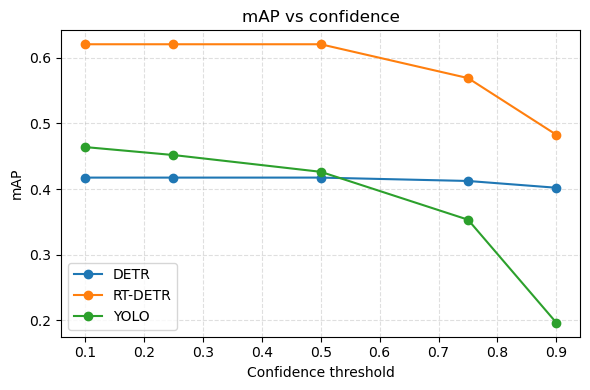

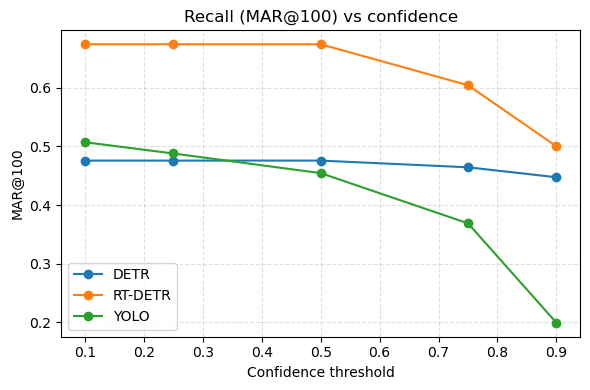

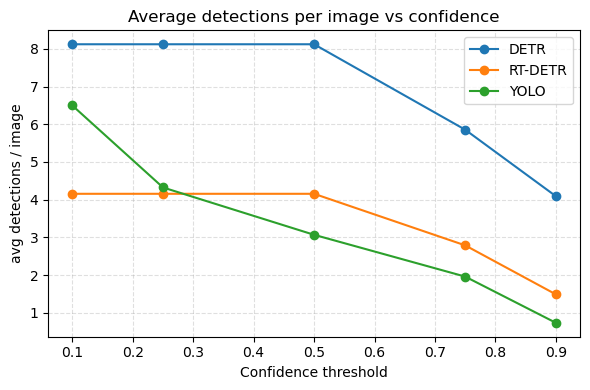

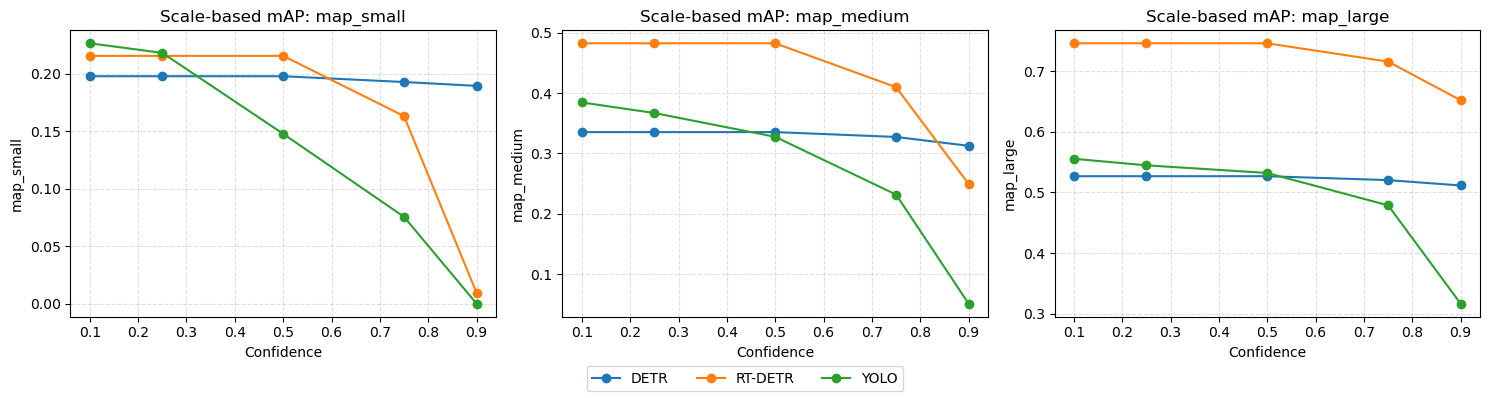

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==== 0. Load results from CSV ====
df_results = pd.read_csv("task1_voc_results.csv")

# Sanity check: make sure results are sorted
df_results = df_results.sort_values(["model", "conf"]).reset_index(drop=True)
display(df_results.head())

# ========== 1. SUMMARY TABLES (EASY TO READ) ==========

def summary_table(metric_name):
    """
    Create a pivot table with models as rows, confidence as columns
    for a given metric.
    """
    pivot = df_results.pivot_table(
        index="model",
        columns="conf",
        values=metric_name
    )
    return pivot

map_table = summary_table("map")
mar_table = summary_table("mar_100")
dets_table = summary_table("avg_dets_per_img")

print("mAP vs confidence:")
display(map_table.round(3))

print("\nMAR@100 vs confidence:")
display(mar_table.round(3))

print("\nAverage detections per image vs confidence:")
display(dets_table.round(2))


# ========== 2. SIMPLE LINE PLOTS: METRIC vs CONFIDENCE ==========

def plot_metric_vs_conf(metric_name, title, ylabel):
    """
    For each model, plot metric_name as a function of confidence.
    """
    plt.figure(figsize=(6, 4))

    for model_name in df_results["model"].unique():
        df_m = df_results[df_results["model"] == model_name]
        confs = df_m["conf"].values
        values = df_m[metric_name].values

        # Sort by confidence to avoid zig-zag lines
        order = np.argsort(confs)
        confs = confs[order]
        values = values[order]

        plt.plot(confs, values, marker="o", label=model_name)

    plt.title(title)
    plt.xlabel("Confidence threshold")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Primary accuracy metric
plot_metric_vs_conf(
    metric_name="map",
    title="mAP vs confidence",
    ylabel="mAP"
)

# Recall metric
plot_metric_vs_conf(
    metric_name="mar_100",
    title="Recall (MAR@100) vs confidence",
    ylabel="MAR@100"
)

# Detection density (helps talk about FP/FN trade-off)
plot_metric_vs_conf(
    metric_name="avg_dets_per_img",
    title="Average detections per image vs confidence",
    ylabel="avg detections / image"
)


# ========== 3. SCALE-BASED METRICS IN ONE FIGURE ==========

def plot_scale_metrics(metric_names, title_prefix):
    """
    For each metric in metric_names, create a subplot showing
    its trend vs confidence for all models.
    """
    n = len(metric_names)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharex=True)

    if n == 1:
        axes = [axes]

    for ax, metric_name in zip(axes, metric_names):
        for model_name in df_results["model"].unique():
            df_m = df_results[df_results["model"] == model_name]
            confs = df_m["conf"].values
            values = df_m[metric_name].values

            order = np.argsort(confs)
            confs = confs[order]
            values = values[order]

            ax.plot(confs, values, marker="o", label=model_name)

        ax.set_title(f"{title_prefix}: {metric_name}")
        ax.set_xlabel("Confidence")
        ax.set_ylabel(metric_name)
        ax.grid(True, linestyle="--", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


# Scale-based mAPs
plot_scale_metrics(
    metric_names=["map_small", "map_medium", "map_large"],
    title_prefix="Scale-based mAP"
)


## Discussion and comments on the results

### Overall Performance Comparison

Across all tested confidence thresholds, RT-DETR consistently achieves the highest overall performance. At low confidence (0.1), it reaches a mAP of 0.621, significantly outperforming YOLO (0.464) and DETR (0.418). This superiority remains visible even as the confidence threshold increases, although all models exhibit performance degradation.

YOLO ranks as the second-best model only at low and medium confidence thresholds, while at high confidence values DETR becomes more competitive and overtakes YOLO. This indicates that YOLO is more sensitive to aggressive thresholding, whereas DETR maintains more stable performance when stricter filtering is applied.

### Effect of Confidence Threshold

The confidence parameter has a clear and predictable impact on all models: 
Increasing the confidence threshold reduces the number of detections per image. This leads to fewer false positives but also increases missed detections (false negatives), reducing recall.

This is clearly reflected in YOLO:

- At conf = 0.1: avg_dets_per_img = 6.50, mAP = 0.464

- At conf = 0.9: avg_dets_per_img = 0.73, mAP = 0.196

A similar trend is seen for RT-DETR:

- At conf = 0.1: mAP = 0.621

- At conf = 0.9: mAP = 0.483

Thus, while higher confidence thresholds produce cleaner predictions, they significantly reduce coverage of ground-truth objects, confirming the classic precision-recall trade-off.

### Scale-Based Performance

Performance varies significantly with object size:

Small objects: YOLO slightly outperforms the other models at low confidence, but its performance drops sharply as the confidence threshold increases. This suggests that YOLO is more sensitive to fine details when detections are less strictly filtered, but struggles to maintain reliable small-object detection under stricter confidence settings.

Medium and large objects: RT-DETR clearly dominates, achieving consistently higher mAP values, especially for large objects (up to 0.746 at conf 0.1).

At high confidence (0.9), all models struggle with small objects, with YOLO completely failing to detect them (mAP_small = 0), showing the vulnerability of high thresholds for small-scale detection.

### Recall Analysis

RT-DETR achieves the highest recall across all thresholds, with MAR@100 = 0.674 at conf 0.1, compared to YOLO’s 0.507 and DETR’s 0.476. Even at high confidence (0.9), RT-DETR maintains a MAR@100 of 0.50, highlighting its ability to retain useful detections while filtering aggressively.

DETR tends to generate the highest number of detections per image, which suggests more false positives but still lower overall accuracy, indicating weaker precision.

### Qualitative Interpretation

Qualitatively, the results suggest:

YOLO is more aggressive at low thresholds, producing many detections and better capturing small objects.

DETR tends to over-predict, generating more boxes but with lower discriminative power.

RT-DETR achieves a better balance, generating fewer but more reliable detections, leading to superior mAP and recall.